# HJ Lightcurve Visual Inspection (Top 30 by Transit Depth)
Loads all Hot Jupiter planets across all batch files, sorted by transit depth descending. Downloads TESS SPOC 2-min lightcurves and plots each planet's sectors in a grid for visual confirmation of transit dips.

> **Note:** Currently 15 unique HJ planets are available across the batch files. Add more batch CSVs to `Final HJ and UHJ/` to extend to 30.

In [4]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
from IPython.display import display

warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
FOLDER   = os.path.join(BASE_DIR, 'Final HJ and UHJ')
NCOLS    = 5
TOP_N    = 30

# Use the dedicated top-30 file directly
hj_all = (
    pd.read_csv(os.path.join(FOLDER, 'hot_jupiters_top30.csv'))
    .drop_duplicates('Planet')
    .sort_values('Transit_depth_pct', ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

print(f'{len(hj_all)} HJ planets loaded (top {TOP_N} by transit depth):')
display(hj_all[['Planet','Period_days','Radius_Rjup','Transit_depth_pct','StarRadius_Rsun','SemiMajorAxis_AU']])

30 HJ planets loaded (top 30 by transit depth):


,Planet,Period_days,Radius_Rjup,Transit_depth_pct,StarRadius_Rsun,SemiMajorAxis_AU
0,WTS-2,1.019,1.363,3.469294,0.7520,0.01855
1,WASP-177,3.072,1.580,3.365989,0.8850,0.03957
2,TOI-3540,3.120,2.100,3.088353,1.2280,0.04289
3,WASP-183,4.112,1.470,3.008039,0.8710,0.04632
4,WASP-052,1.750,1.300,2.888861,0.7860,0.02643
5,CoRoT-02,1.743,1.460,2.772945,0.9010,0.02835
6,Kepler-447,7.794,1.650,2.710057,1.0300,0.07690
7,NGTS-03,1.675,1.480,2.674500,0.9300,0.02330
8,TrES-3,1.306,1.310,2.672394,0.8235,0.02276
9,TOI-1855,1.364,1.650,2.653087,1.0410,0.02398


In [5]:
R_sun = 6.957e8
R_jup = 7.149e7
AU    = 1.496e11

def estimate_T14(P_days, R_star_rsun, R_p_rjup, a_AU):
    R_s = R_star_rsun * R_sun
    R_p = R_p_rjup   * R_jup
    a   = a_AU * AU
    return (P_days / np.pi) * np.arcsin(np.clip((R_s + R_p) / a, 0, 1))

def clean_lc(lc, sigma=3.0):
    lc   = lc.remove_nans().remove_outliers(sigma=sigma)
    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)
    flux = flux / np.nanmedian(flux)
    return time, flux

PLANET_PARAMS = {}
for _, row in hj_all.iterrows():
    planet = row['Planet']
    P      = row['Period_days']
    T14_d  = estimate_T14(P, row['StarRadius_Rsun'], row['Radius_Rjup'], row['SemiMajorAxis_AU'])
    PLANET_PARAMS[planet] = dict(P=P, T14_d=T14_d, T14_h=T14_d*24,
                                 R_b=row['Radius_Rjup'], depth=row['Transit_depth_pct'])

param_summary = pd.DataFrame([
    {'Planet': k, 'Period_days': v['P'], 'T14_h': round(v['T14_h'], 2),
     'depth_%': round(v['depth'], 3), 'R_b_Rjup': v['R_b']}
    for k, v in PLANET_PARAMS.items()
])
print('Estimated T14 for all HJ planets:')
display(param_summary)

Estimated T14 for all HJ planets:


,Planet,Period_days,T14_h,depth_%,R_b_Rjup
0,WTS-2,1.019,1.76,3.469,1.363
1,WASP-177,3.072,2.90,3.366,1.580
2,TOI-3540,3.120,3.75,3.088,2.100
3,WASP-183,4.112,3.23,3.008,1.470
4,WASP-052,1.750,2.17,2.889,1.300
5,CoRoT-02,1.743,2.31,2.773,1.460
6,Kepler-447,7.794,4.32,2.710,1.650
7,NGTS-03,1.675,2.79,2.674,1.480
8,TrES-3,1.306,1.97,2.672,1.310
9,TOI-1855,1.364,2.47,2.653,1.650


## Lightcurve Grid — All HJ Planets
One figure per planet, one subplot per sector. No overlays — raw flux only so dips are directly visible.

[WTS-2] Downloading...
  8 sector(s) — plotting...


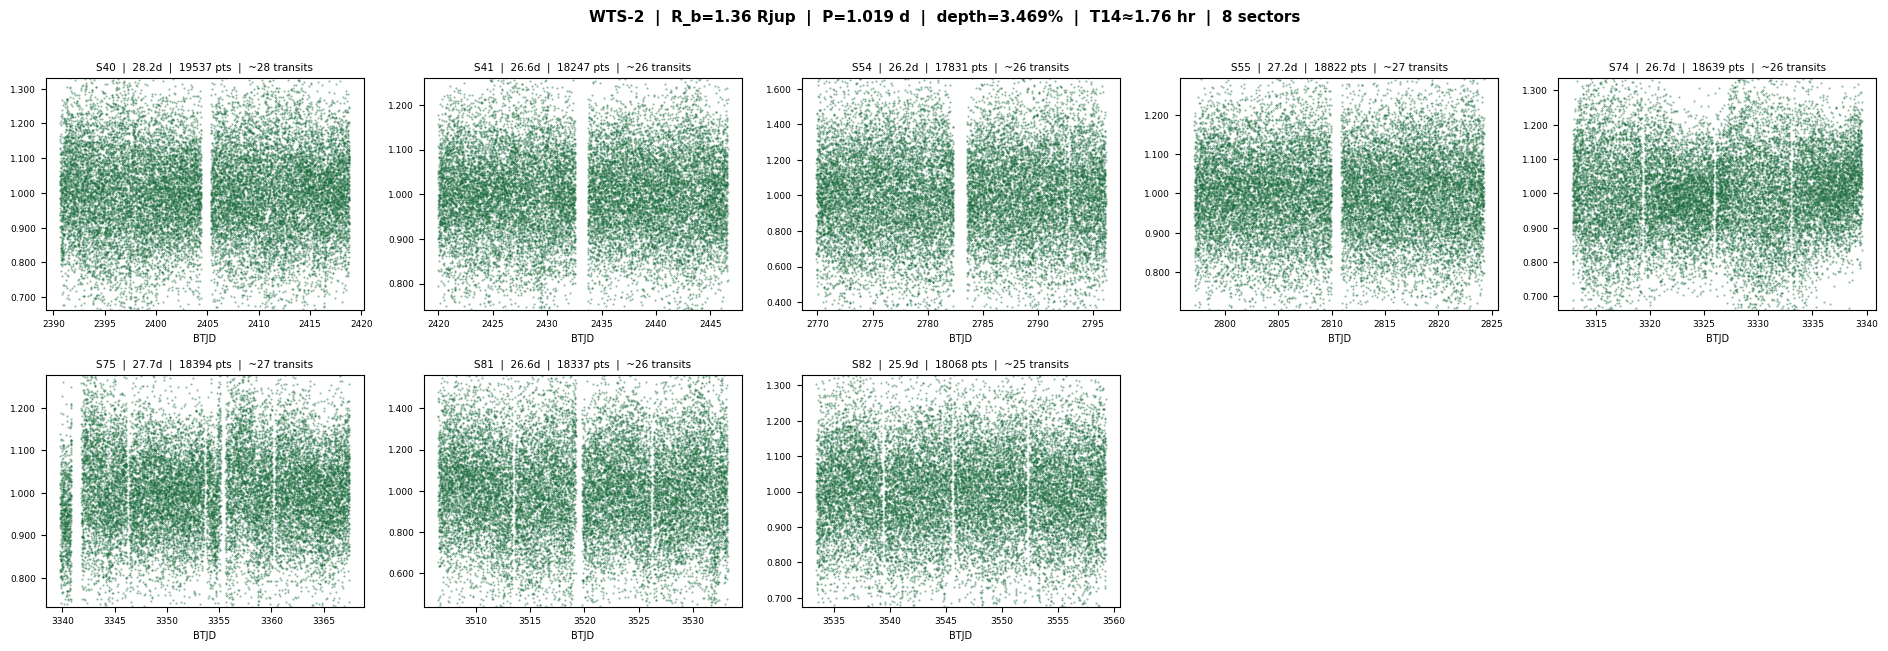

  Done.

[WASP-177] Downloading...
  4 sector(s) — plotting...


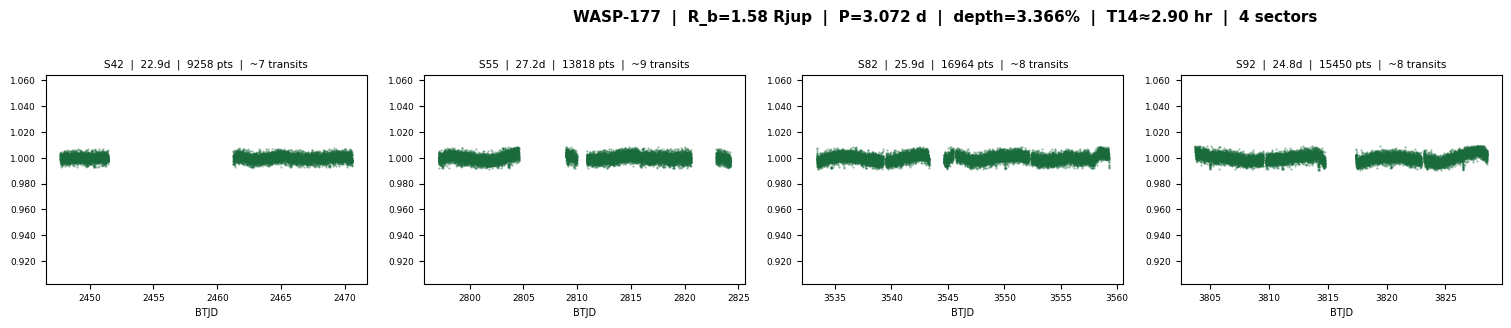

  Done.

[TOI-3540] Downloading...
  3 sector(s) — plotting...


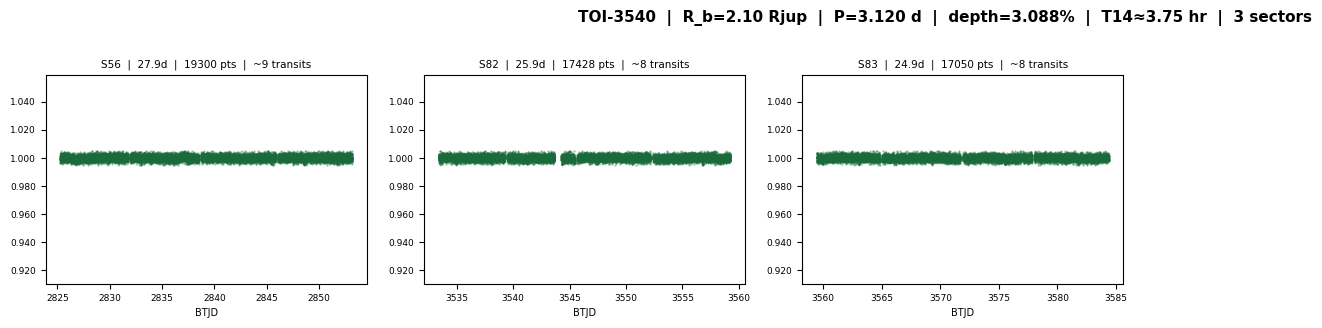

  Done.

[WASP-183] Downloading...
  4 sector(s) — plotting...


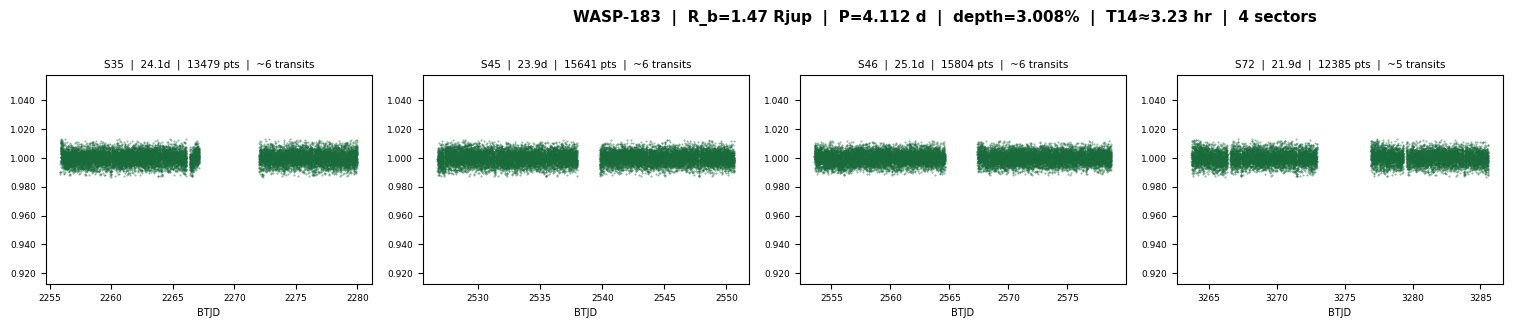

  Done.

[WASP-052] Downloading...
  1 sector(s) — plotting...


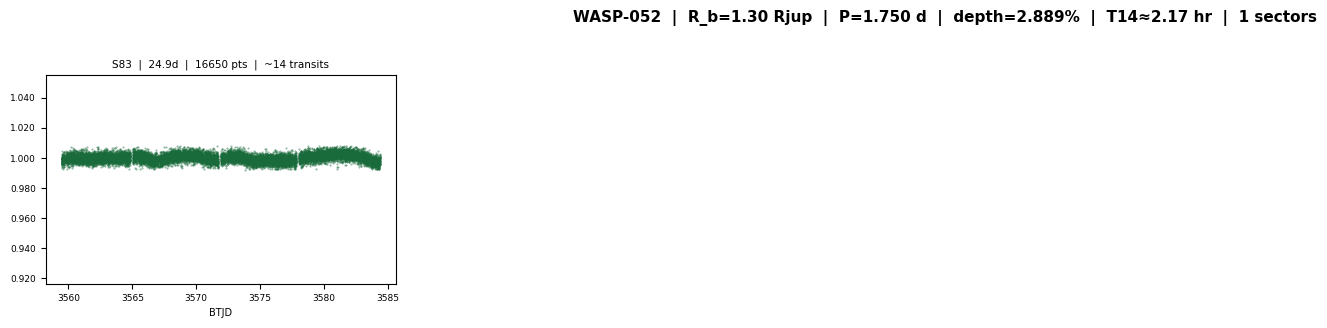

  Done.

[CoRoT-02] Downloading...


  2 sector(s) — plotting...


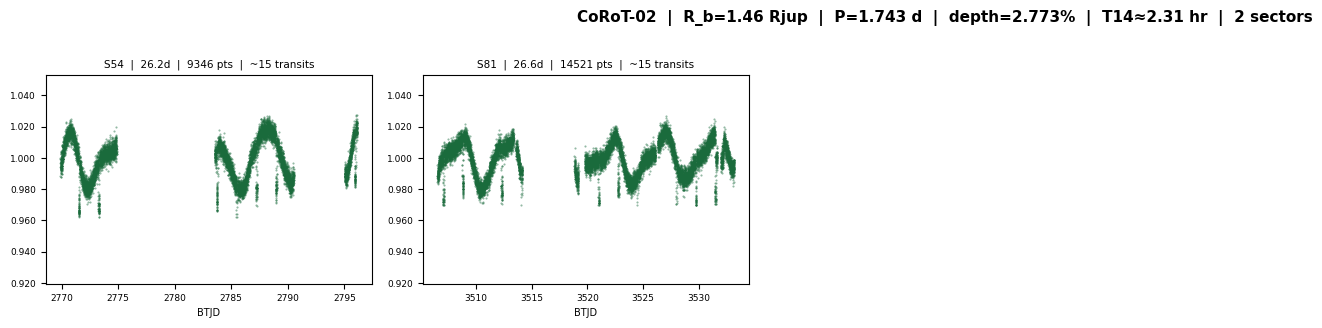

  Done.

[Kepler-447] Downloading...
  10 sector(s) — plotting...


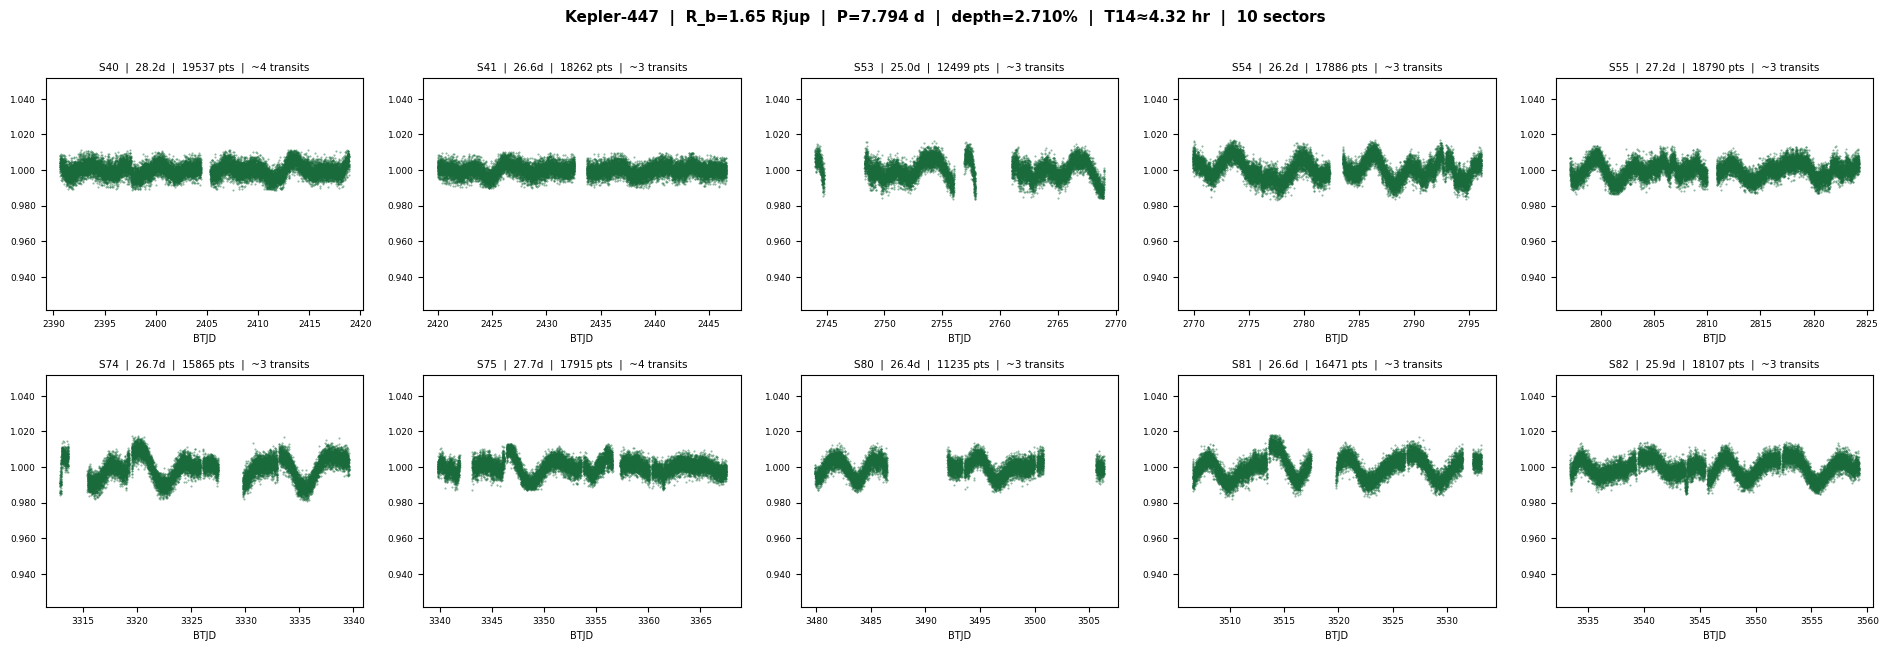

  Done.

[NGTS-03] Downloading...
  3 sector(s) — plotting...


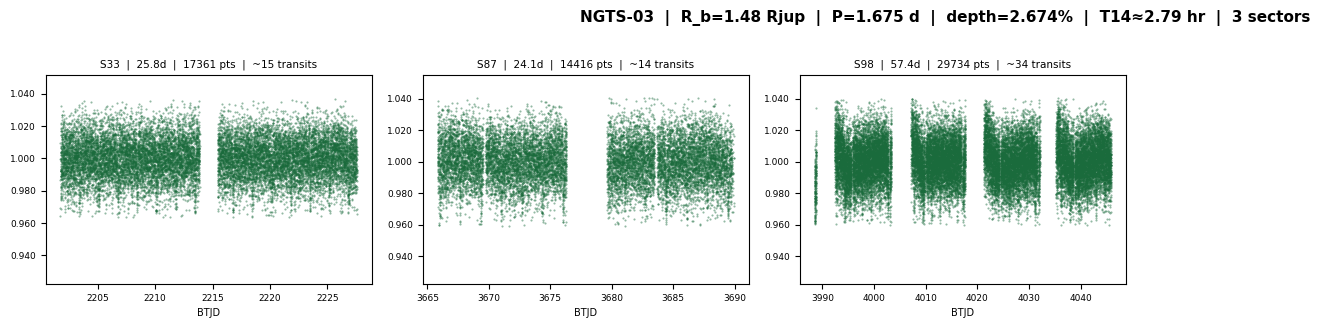

  Done.

[TrES-3] Downloading...
  7 sector(s) — plotting...


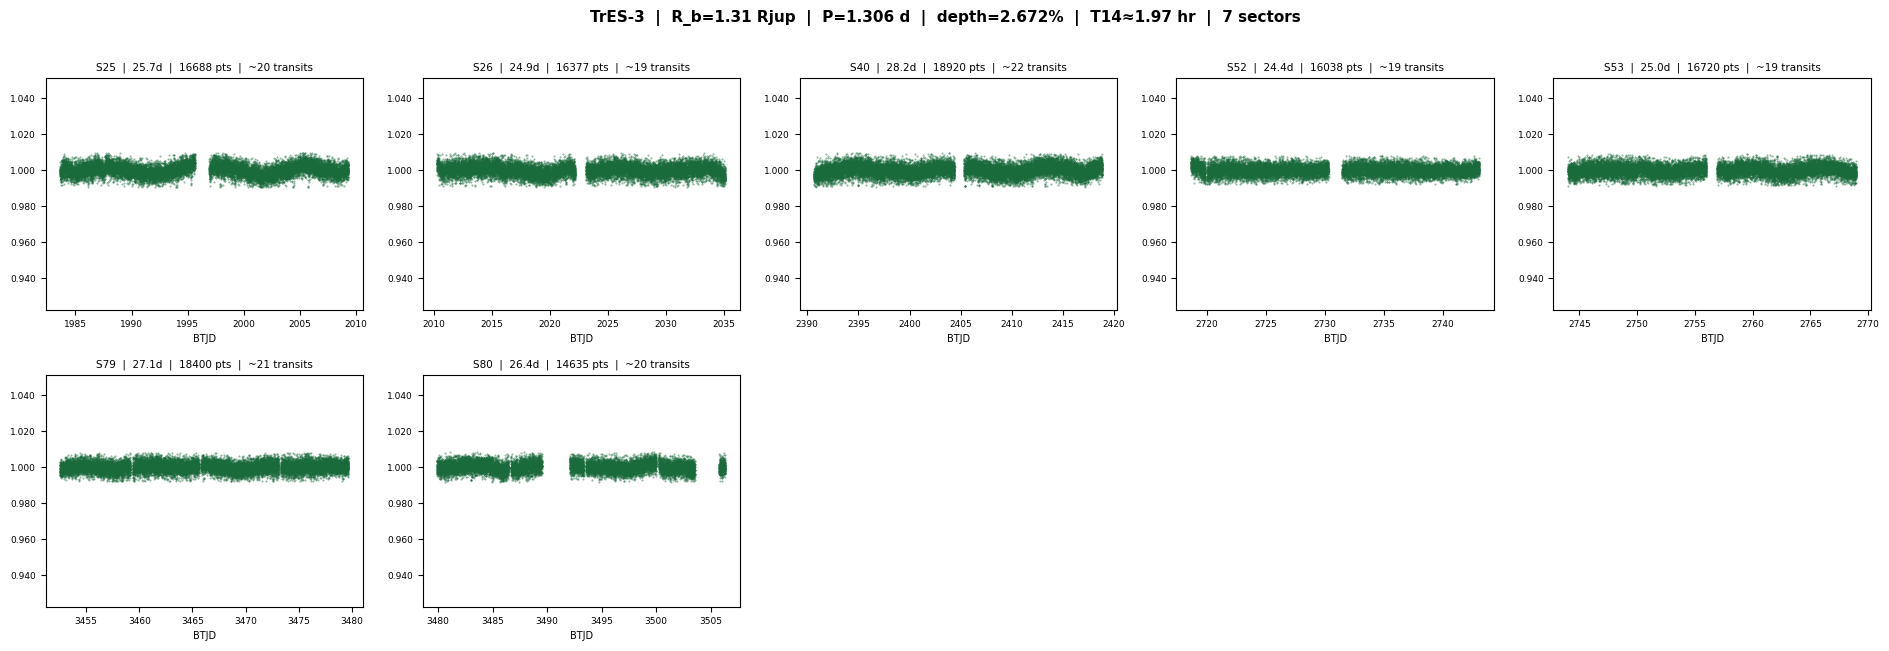

  Done.

[TOI-1855] Downloading...


  1 sector(s) — plotting...


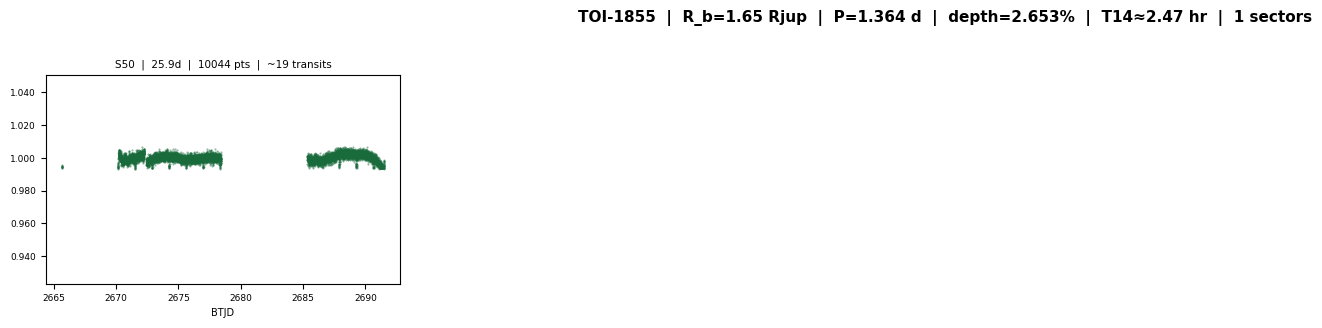

  Done.

[HATS-23] Downloading...
  3 sector(s) — plotting...


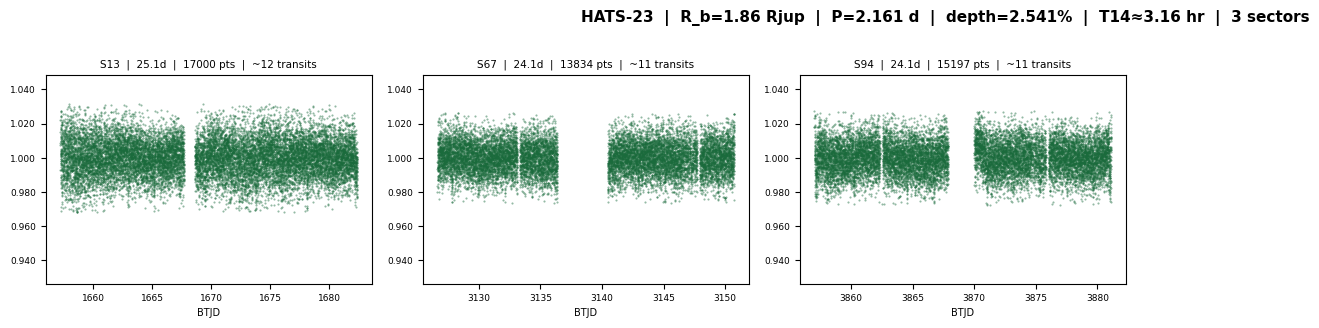

  Done.

[WASP-098] Downloading...
  2 sector(s) — plotting...


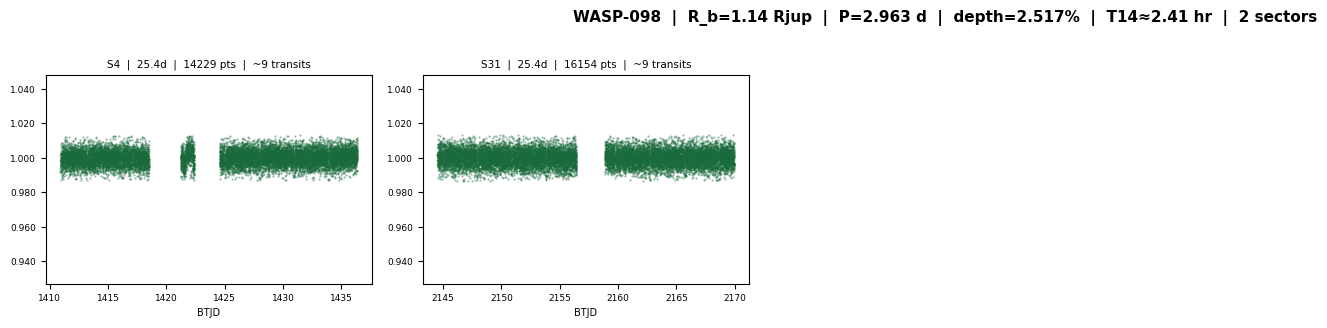

  Done.

[NGTS-05] Downloading...


  1 sector(s) — plotting...


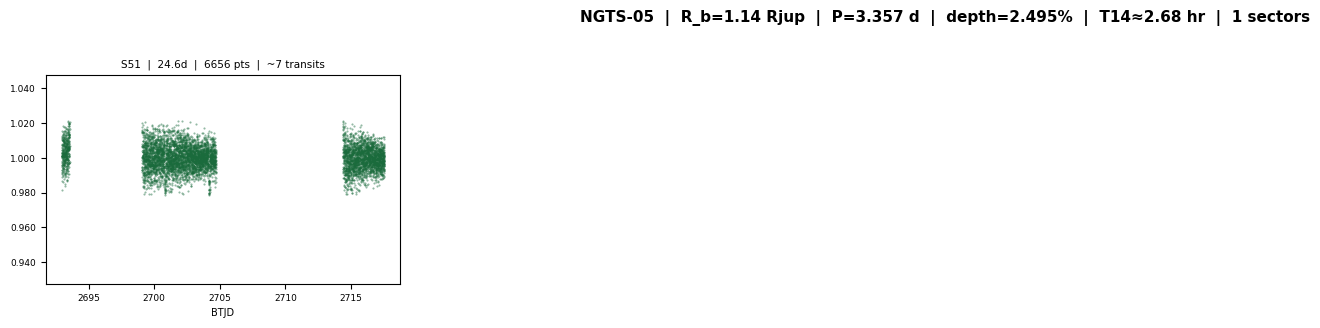

  Done.

[HD_189733] Downloading...
  3 sector(s) — plotting...


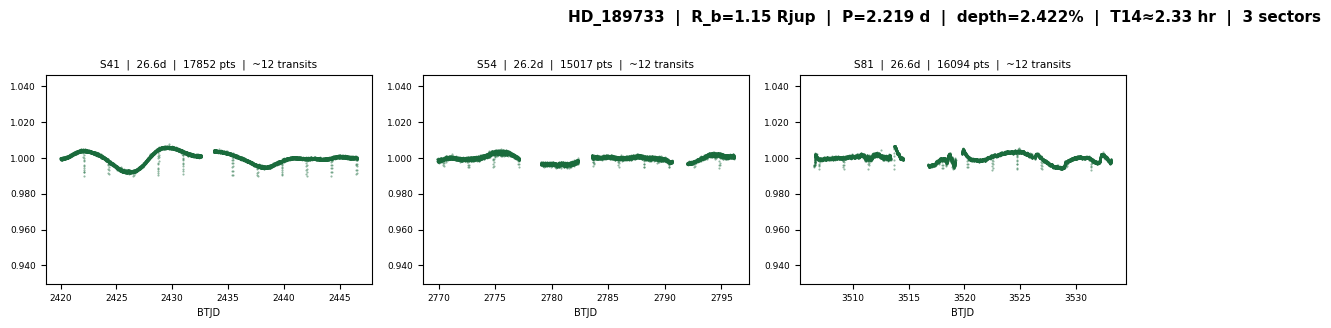

  Done.

[TOI-2796] Downloading...
  Download error: Error in reading Data product C:\Users\pnayg\.lightkurve\cache\mastDownload\TESS\tess2025312202959-s0098-0000000220076110-0298-s\tess2025312202959-s0098-0000000220076110-0298-s_lc.fits of type TessLightCurve .
This file may be corrupt due to an interrupted download. Please remove it from your disk and try again.

[Qatar-6] Downloading...
  No SPOC 2-min data found — skipped.

[WASP-004] Downloading...
  5 sector(s) — plotting...


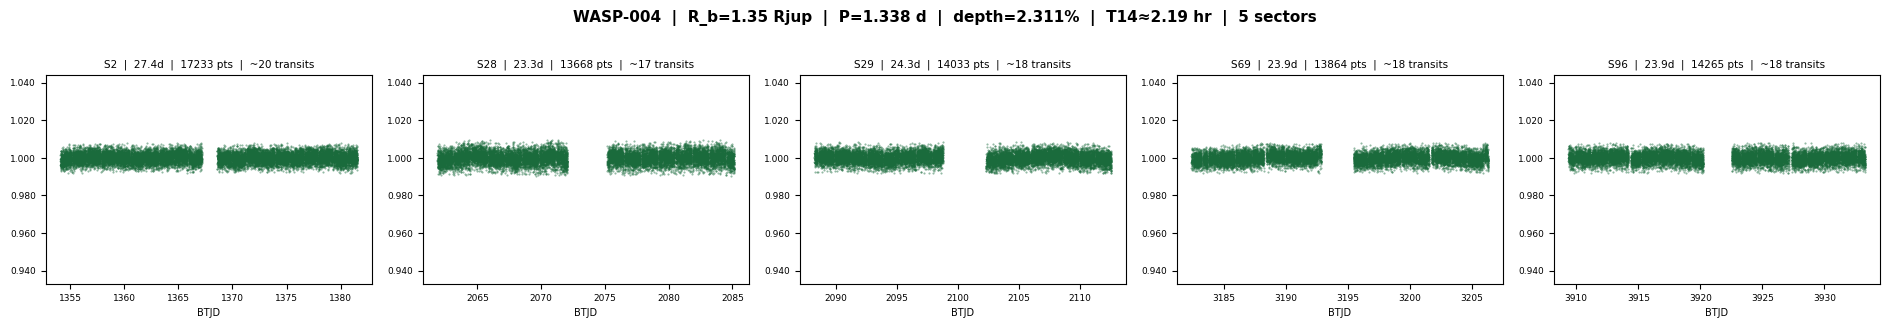

  Done.

[HAT-P-32] Downloading...
  1 sector(s) — plotting...


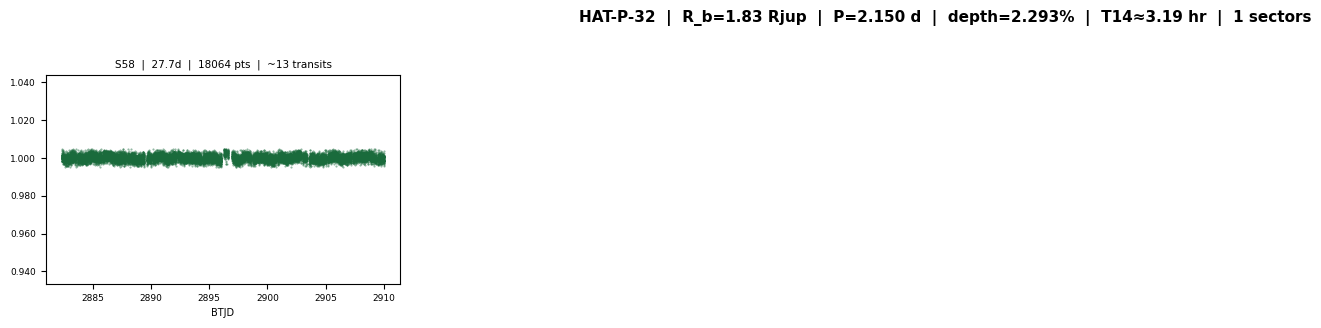

  Done.

[WASP-140] Downloading...
  3 sector(s) — plotting...


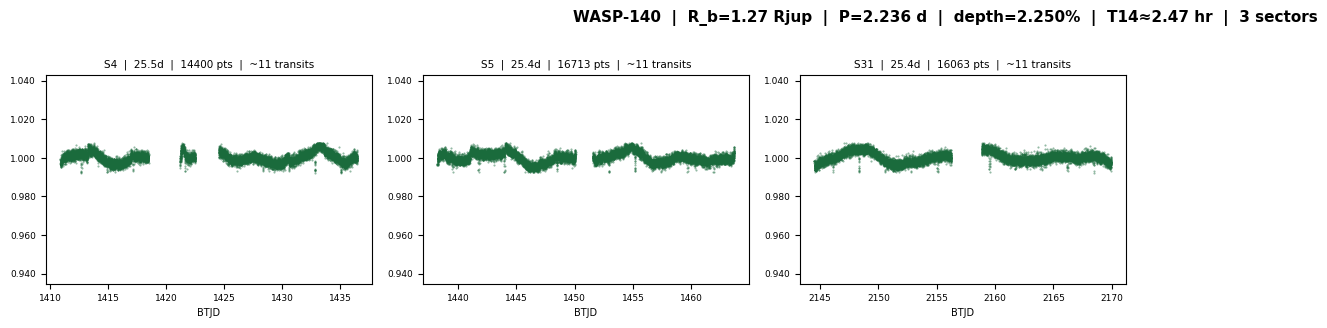

  Done.

[TOI-1408b] Downloading...
  18 sector(s) — plotting...


KeyboardInterrupt: 

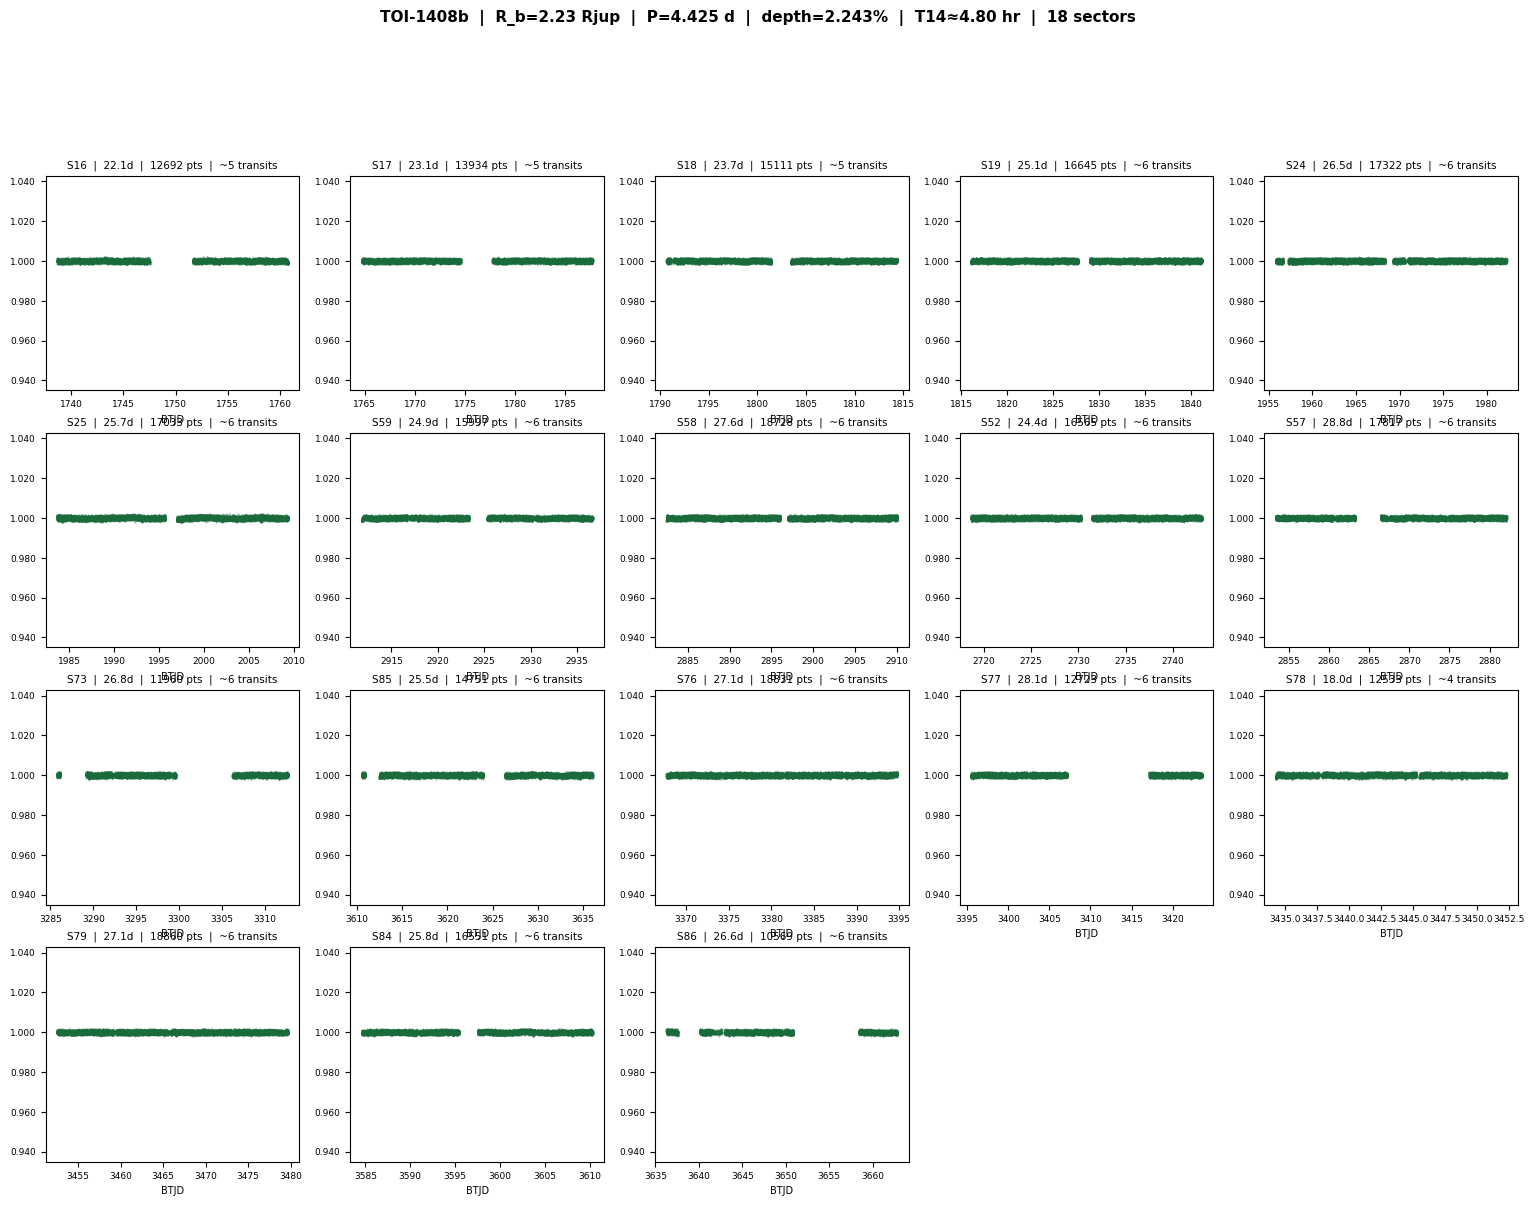

In [6]:
for planet, p in PLANET_PARAMS.items():
    P      = p['P']
    T14_d  = p['T14_d']
    T14_h  = p['T14_h']
    R_b    = p['R_b']
    depth  = p['depth']

    print(f'[{planet}] Downloading...', flush=True)
    try:
        sr = lk.search_lightcurve(planet, mission='TESS', cadence=120, author='SPOC')
        if len(sr) == 0:
            print(f'  No SPOC 2-min data found — skipped.\n')
            continue
        lc_collection = sr.download_all(quality_bitmask='default')
    except Exception as e:
        print(f'  Download error: {e}\n')
        continue

    n_sectors = len(lc_collection)
    nrows     = math.ceil(n_sectors / NCOLS)
    print(f'  {n_sectors} sector(s) — plotting...', flush=True)

    fig, axes = plt.subplots(nrows, NCOLS,
                             figsize=(NCOLS * 3.8, nrows * 3.2),
                             squeeze=False)
    fig.suptitle(
        f'{planet}  |  R_b={R_b:.2f} Rjup  |  P={P:.3f} d  |  '
        f'depth={depth:.3f}%  |  T14≈{T14_h:.2f} hr  |  {n_sectors} sectors',
        fontsize=11, fontweight='bold', y=1.01
    )

    depth_frac = depth / 100.0

    for idx, lc_raw in enumerate(lc_collection):
        row_i      = idx // NCOLS
        col_i      = idx  % NCOLS
        ax         = axes[row_i][col_i]
        sector_num = lc_raw.meta.get('SECTOR', '?')

        try:
            time, flux = clean_lc(lc_raw)
        except Exception as e:
            ax.set_title(f'S{sector_num} — error', fontsize=8)
            ax.axis('off')
            continue

        span_d    = time[-1] - time[0]
        n_transit = round(span_d / P)

        ax.plot(time, flux, '.', ms=1.0, color='#1a6b3c', alpha=0.5, zorder=2)

        # Y-limits: always show at least 3x the transit depth below 1.0
        flux_p1  = np.nanpercentile(flux, 1)
        flux_p99 = np.nanpercentile(flux, 99)
        margin   = max(3 * depth_frac, (flux_p99 - flux_p1) * 0.1, 0.002)
        ylo = min(flux_p1,  1.0 - 2 * depth_frac) - margin * 0.3
        yhi = max(flux_p99, 1.0 + depth_frac)     + margin * 0.3
        ax.set_ylim(ylo, yhi)

        ax.set_title(
            f'S{sector_num}  |  {span_d:.1f}d  |  {len(time)} pts  |  ~{n_transit} transits',
            fontsize=7.5
        )
        ax.set_xlabel('BTJD', fontsize=7)
        ax.tick_params(labelsize=6.5)
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

    for idx in range(n_sectors, nrows * NCOLS):
        axes[idx // NCOLS][idx % NCOLS].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'  Done.\n', flush=True)